<a href="https://colab.research.google.com/github/mohand22yehia-commits/telecome_egypt_assigment/blob/main/WE_ML_Complaint_Classification_Summarization_Sentiment_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/0/0f/We_logo.svg/3840px-We_logo.svg.png" alt="WE Logo" width="60" style="margin-bottom:8px"/>

# Telecom Egypt (WE) — ML Project
## Customer Complaint Classification, Summarization & Sentiment Analysis

---

### Background

Telecom Egypt (WE) receives thousands of customer support tickets every day across multiple channels — call center transcripts, the WE app chat, and social media comments. Today, agents read every ticket in full before they can tag its category, gauge how upset the customer is, and decide who should handle it first. This is slow, inconsistent between agents, and makes it hard to spot urgent cases early.

This project simulates a real-world NLP task at WE. You are part of the Data & AI team, and — unlike the Smart Plan project — **there is no historical ticket dataset waiting for you.** The Customer Care team has never systematically logged ticket text before, so before you can train anything, you first have to **construct a realistic synthetic dataset** yourselves, then use it to build an NLP pipeline that, given the raw text of a customer ticket, can:

> **Classify** — which department/category should own this ticket (Billing, Network, Technical Support, Sales/Plans, Other)
> **Summarize** — reduce a long, messy complaint into a 1–2 sentence summary an agent can read in seconds
> **Detect Sentiment** — flag whether the customer is Positive, Neutral, or Negative, so angry customers can be prioritized



---

### General Instructions

- Read each step carefully before writing any code.
- Each step has a clear objective — understand **why** you are doing it, not just **how**.
- Ticket text should be messy on purpose: Arabic, English, Franco-Arabic (Arabic written in Latin letters), emojis, and typos. A too-clean synthetic dataset will teach you nothing about real preprocessing challenges.
- You are expected to make decisions along the way (e.g., how many categories, how imbalanced, how to simulate missing ratings). Document your reasoning in markdown cells.
- There is no single correct answer — justify your choices.


In [2]:
categories = ['Billing', 'Network', 'Technical Support', 'Sales/Plans', 'Other']
columns = [
    'TICKET_ID#',
    'SUBSCRIBER_ID#',
    'CHANNEL',
    'TICKET_TEXT',
    'CATEGORY',
    'RATING',
    'CREATED_DATE'
]
print(f"Categories defined: {categories}")
print(f"Dataset columns defined: {columns}")

Categories defined: ['Billing', 'Network', 'Technical Support', 'Sales/Plans', 'Other']
Dataset columns defined: ['TICKET_ID#', 'SUBSCRIBER_ID#', 'CHANNEL', 'TICKET_TEXT', 'CATEGORY', 'RATING', 'CREATED_DATE']


In [3]:
templates = {
    'Billing': [
        "فاتورتي الشهر ده عالية اوي، ليه خصمتوا {amount} جنيه زيادة؟",
        "I was overcharged {amount} for my last bill. Please check.",
        "fatora 3alya awy el shahr da, leh keda??",
        "The payment of {amount} failed but the money was taken from my account.",
        "مش فاهم ليه في {amount} جنيه زيادة على الفاتورة؟"
    ],
    'Network': [
        "الشبكة وحشة جدا في منطقة {location}، مفيش 4G خالص.",
        "No signal at home since this morning. Network is down.",
        "el shabaka wa7sha awy f {location}, msh عارف اتكلم.",
        "Internet is extremely slow today, I can't even open a website.",
        "النت بيفصل كل شوية والسرعة زفت."
    ],
    'Technical Support': [
        "الراوتر مش شغال واللمبة الحمراء منورة.",
        "My router is blinking red and I've tried restarting it many times.",
        "el router msh shaghal, el lamba el 7amra monawara.",
        "I need help configuring my new router settings.",
        "مش عارف ادخل على اعدادات الراوتر، ممكن مساعدة؟"
    ],
    'Sales/Plans': [
        "عايز احول لنظام {plan} الجديد، ايه الشروط؟",
        "I want to upgrade my current plan to {plan}. How much does it cost?",
        "3ayez a7awel le nizam {plan}, help me plz.",
        "Are there any new offers for the {plan} internet package?",
        "ممكن تفاصيل أكتر عن باقات {plan} المتاحة حالياً؟"
    ],
    'others': [
        "الفرع اللي في {location} زحمة جدا والموظفين بطيئين.",
        "The customer service at the store was very rude.",
        "el mozafen f far3 {location} mo3amlethom wa7sha.",
        "How can I talk to a human agent? The automated system is annoying.",
        "مستوى الخدمة في تراجع مستمر."
    ]
}

print("Templates fixed and verified for categories:", list(templates.keys()))

Templates fixed and verified for categories: ['Billing', 'Network', 'Technical Support', 'Sales/Plans', 'others']


In [4]:
import random
import re

locations = ['Maadi', 'Zamalek', 'Nasr City', 'Alexandria', 'Giza', 'Dokki', 'October City']
plans = ['WE Space Basic', 'WE Space Pro', 'Kix 35', 'Indigo 150', 'Super Mega']

def add_noise(text):
    """Injects typos, repeated punctuation, and emojis into the text."""
    if random.random() < 0.3:
        text = text.replace('?', '??').replace('!', '!!!')
    if len(text) > 10 and random.random() < 0.1:
        idx = random.randint(0, len(text) - 2)
        text = text[:idx] + text[idx+1] + text[idx] + text[idx+2:]
    return text

def generate_ticket_text(category):
    """Picks a template and fills placeholders."""
    template = random.choice(templates[category])
    ticket = template.format(
        amount=random.randint(50, 500),
        location=random.choice(locations),
        plan=random.choice(plans)
    )
    return add_noise(ticket)

print(f"Sample Billing: {generate_ticket_text('Billing')}")
print(f"Sample Network: {generate_ticket_text('Network')}")

Sample Billing: مش فاهم ليه في 481 جنيه زيادة على الفاتورة؟
Sample Network: الشبكة وحشة جدا في منطقة Dokki، مفيش 4G خالص.


In [5]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

num_tickets = 1000
category_probs = [0.35, 0.30, 0.15, 0.10, 0.10]
data = []
start_date = datetime(2023, 10, 1)

for i in range(num_tickets):
    category = np.random.choice(categories, p=category_probs)
    if category == 'Other':
        category_for_template = 'others'
    else:
        category_for_template = category
    ticket_text = generate_ticket_text(category_for_template)
    channel = random.choice(['Call Center', 'App Chat', 'Social Media'])
    created_date = start_date + timedelta(days=random.randint(0, 90))

    if category in ['Network', 'Billing']:
        rating = np.random.choice([1, 2, 3, 4, 5], p=[0.4, 0.3, 0.2, 0.05, 0.05])
    else:
        rating = np.random.choice([1, 2, 3, 4, 5], p=[0.1, 0.2, 0.3, 0.3, 0.1])
    if random.random() < 0.4:
        rating = np.nan
    data.append({
        'TICKET_ID#': f"TK-{10000 + i}",
        'SUBSCRIBER_ID#': f"SUB-{random.randint(100000, 999999)}",
        'CHANNEL': channel,
        'TICKET_TEXT': ticket_text,
        'CATEGORY': str(category),
        'RATING': rating,
        'CREATED_DATE': created_date.strftime('%Y-%m-%d')
    })
df = pd.DataFrame(data)
print(f"Generated {len(df)} records.")
print("Category distribution:\n", df['CATEGORY'].value_counts(normalize=True))
print(f"\nMissing ratings: {df['RATING'].isna().sum()} ({df['RATING'].isna().mean():.1%})")

Generated 1000 records.
Category distribution:
 CATEGORY
Billing              0.347
Network              0.281
Technical Support    0.167
Other                0.103
Sales/Plans          0.102
Name: proportion, dtype: float64

Missing ratings: 405 (40.5%)


In [6]:
df.to_csv('Tickets.csv', index=False)
print("Successfully saved synthetic dataset to 'Tickets.csv'.")
display(df.head())
import os
file_size = os.path.getsize('Tickets.csv') / 1024
print(f"\nFile size: {file_size:.2f} KB")

Successfully saved synthetic dataset to 'Tickets.csv'.


,TICKET_ID#,SUBSCRIBER_ID#,CHANNEL,TICKET_TEXT,CATEGORY,RATING,CREATED_DATE
0,TK-10000,SUB-576250,Social Media,I need help configuring my new router settings.,Technical Support,NaN,2023-11-14
1,TK-10001,SUB-147223,Social Media,النت بيفصل كل شوية والسرعة زفت.,Network,NaN,2023-10-24
2,TK-10002,SUB-940759,Social Media,I was overcharged 442 for my last bill. Please...,Billing,NaN,2023-12-25
3,TK-10003,SUB-632495,Social Media,I was overcharged 129 for my last bill. Please...,Billing,1.0,2023-10-16
4,TK-10004,SUB-370993,App Chat,مش فاهم ليه في 462 جنيه زيادة على الفاتورة؟,Billing,1.0,2023-11-08



File size: 116.92 KB


---
## Step 2 — Load & Explore the Data

### Objective
Treat your synthetic dataset the way you'd treat any real one — verify it before trusting it.

### Why This Step Matters
Even data you generated yourself can have bugs: a template that never fires, a rating distribution that's accidentally uniform, categories that leak keywords too obviously. Catching that now saves you from building a pipeline on broken assumptions.

### What To Do
- Load `Tickets.csv`; print shape, dtypes, and a few sample rows.
- Check for missing values, especially in `RATING`.
- Compute and visualize `TICKET_TEXT` length (word count and character count) — histogram.
- Visualize the distribution of `CHANNEL` and `CATEGORY`.
- Print 5–10 random raw tickets to sanity-check the language style and noise you generated.

**Expected Output:** At least 4 visualizations. Write a short observation below each one — including whether the data "looks" realistic enough to proceed.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
sns.set_theme(style="whitegrid")
print("Core libraries and NLTK resources imported successfully.")

Core libraries and NLTK resources imported successfully.


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('Tickets.csv')
print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
display(df.head())

Dataset Shape: (1000, 7)

Data Types:
TICKET_ID#         object
SUBSCRIBER_ID#     object
CHANNEL            object
TICKET_TEXT        object
CATEGORY           object
RATING            float64
CREATED_DATE       object
dtype: object


,TICKET_ID#,SUBSCRIBER_ID#,CHANNEL,TICKET_TEXT,CATEGORY,RATING,CREATED_DATE
0,TK-10000,SUB-576250,Social Media,I need help configuring my new router settings.,Technical Support,NaN,2023-11-14
1,TK-10001,SUB-147223,Social Media,النت بيفصل كل شوية والسرعة زفت.,Network,NaN,2023-10-24
2,TK-10002,SUB-940759,Social Media,I was overcharged 442 for my last bill. Please...,Billing,NaN,2023-12-25
3,TK-10003,SUB-632495,Social Media,I was overcharged 129 for my last bill. Please...,Billing,1.0,2023-10-16
4,TK-10004,SUB-370993,App Chat,مش فاهم ليه في 462 جنيه زيادة على الفاتورة؟,Billing,1.0,2023-11-08


In [9]:
print("Missing values per column:")
print(df.isnull().sum())
missing_rating_pct = df['RATING'].isnull().mean() * 100
print(f"\nMissing Rating Percentage: {missing_rating_pct:.2f}%")

Missing values per column:
TICKET_ID#          0
SUBSCRIBER_ID#      0
CHANNEL             0
TICKET_TEXT         0
CATEGORY            0
RATING            405
CREATED_DATE        0
dtype: int64

Missing Rating Percentage: 40.50%


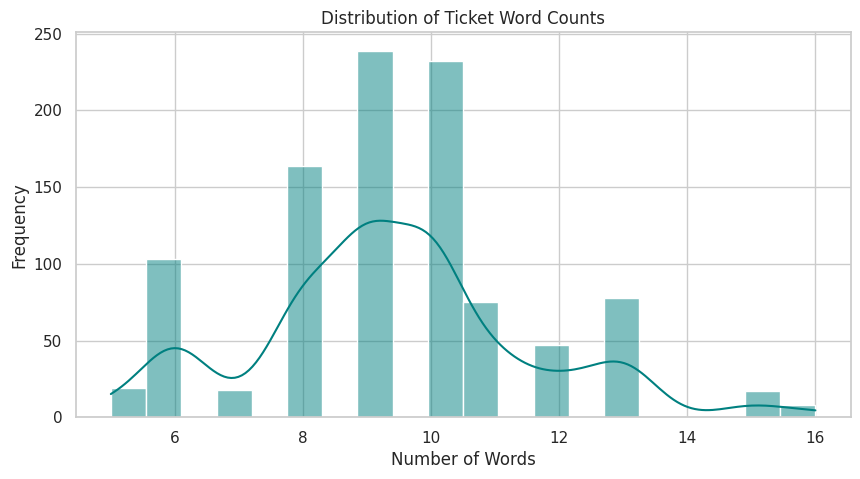

        char_count   word_count
count  1000.000000  1000.000000
mean     49.949000     9.408000
std      10.441716     2.124158
min      28.000000     5.000000
25%      43.000000     8.000000
50%      50.000000     9.000000
75%      54.000000    10.000000
max      76.000000    16.000000


In [10]:
df['char_count'] = df['TICKET_TEXT'].str.len()
df['word_count'] = df['TICKET_TEXT'].str.split().str.len()
plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], bins=20, kde=True, color='teal')
plt.title('Distribution of Ticket Word Counts')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()
print(df[['char_count', 'word_count']].describe())

/tmp/ipykernel_1903/3446456324.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='CATEGORY', ax=axes[0], palette='viridis', order=df['CATEGORY'].value_counts().index)
/tmp/ipykernel_1903/3446456324.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='CHANNEL', ax=axes[1], palette='magma')


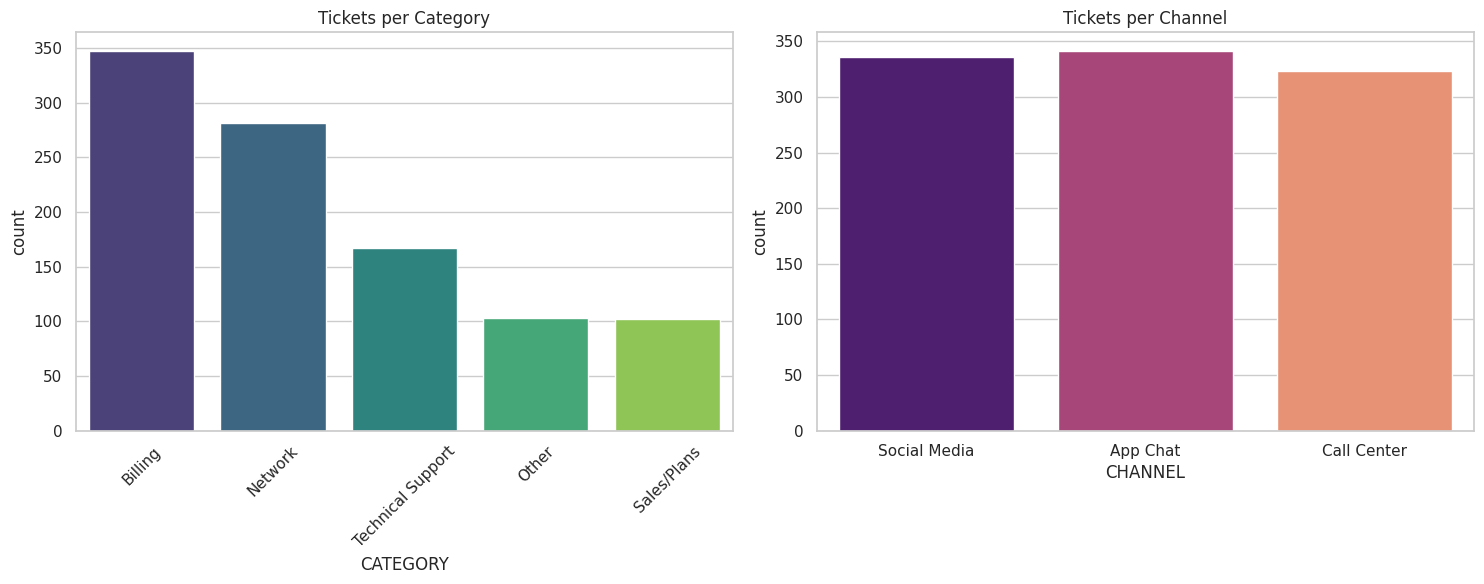

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.countplot(data=df, x='CATEGORY', ax=axes[0], palette='viridis', order=df['CATEGORY'].value_counts().index)
axes[0].set_title('Tickets per Category')
axes[0].tick_params(axis='x', rotation=45)
sns.countplot(data=df, x='CHANNEL', ax=axes[1], palette='magma')
axes[1].set_title('Tickets per Channel')
plt.tight_layout()
plt.show()

In [12]:
print("Displaying 10 random raw tickets for sanity check:\n")
sample_tickets = df['TICKET_TEXT'].sample(10, random_state=42)
for i, ticket in enumerate(sample_tickets, 1):
    print(f"{i}. {ticket}")
    print("-" * 30)

Displaying 10 random raw tickets for sanity check:

1. el mozafen f far3 Maadi mo3amlethom wa7sha.
------------------------------
2. I need helpc onfiguring my new router settings.
------------------------------
3. el mozafen f far3 Zamalek mo3amlethom wa7sha.
------------------------------
4. النت بيفصل كل شوية والسرعة زفت.
------------------------------
5. I was voercharged 258 for my last bill. Please check.
------------------------------
6. 3ayez a7awel le nizam WE Space Pro, help me plz.
------------------------------
7. فاتورتي الشهر ده عالي ةاوي، ليه خصمتوا 334 جنيه زيادة؟
------------------------------
8. I want to upgrade my current plan to Indigo 150. How much does it cost?
------------------------------
9. No signal at home since this morning. Network is down.
------------------------------
10. I was overcharged 432 for my last bill. Please check.
------------------------------


---
## Step 3 — Text Cleaning & Preprocessing

### Objective
Turn raw, noisy ticket text into a clean, model-ready format.

### Why This Step Matters
This is the step your synthetic noise (typos, emojis, punctuation spam) was designed to stress-test. Models trained on unclean text learn noise instead of signal.

### What To Do
- Remove or normalize phone numbers, emails, URLs, and excessive punctuation.
- Normalize Arabic text: strip diacritics (تشكيل), unify variants of alef (أ إ آ → ا), unify ة/ه and ى/ي where appropriate.
- Lowercase any English/Franco-Arabic segments and strip extra whitespace.
- Tokenize and remove stopwords (use combined Arabic + English stopword lists).
- Create a `clean_text` column and a `clean_word_count` column.
- Print a before/after comparison for 5 sample tickets.

> **Watch out for:** Over-cleaning can destroy meaning you need later — e.g., don't strip negation words like "مش" / "not", they flip sentiment entirely.


In [13]:
def normalize_arabic(text):
    """Standardize Arabic characters and remove diacritics."""
    if not isinstance(text, str):
        return ""
    tashkeel = re.compile(r'[\u0617-\u061A\u064B-\u0652]')
    text = re.sub(tashkeel, "", text)
    text = re.sub("[أإآ]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ة", "ه", text)
    return text
test_ar = "أنا غاضب جداً من الفاتورة الجديدة!"
print(f"Original: {test_ar}")
print(f"Normalized: {normalize_arabic(test_ar)}")

Original: أنا غاضب جداً من الفاتورة الجديدة!
Normalized: انا غاضب جدا من الفاتوره الجديده!


In [14]:


def remove_phone_numbers(text):
    if not isinstance(text, str): return text
    return re.sub(r'\+?\d{1,4}[-.\s]?\(?\d{1,}\)?[-.\s]?\d{1,}[-.\s]?\d{1,}', '', text)

def remove_extra_punctuation(text):
    if not isinstance(text, str): return text
    text = re.sub(r'([!?])\1+', r'\1', text)
    text = re.sub(r'[^\w\s!?]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
print("Noise removal applied. A 'temp_clean_text' column has been created for further processing.")
for i in range(3):
    print(f"Original: {df['TICKET_TEXT'].iloc[i]}")


Noise removal applied. A 'temp_clean_text' column has been created for further processing.
Original: I need help configuring my new router settings.
Original: النت بيفصل كل شوية والسرعة زفت.
Original: I was overcharged 442 for my last bill. Please check.


In [17]:
import nltk
from nltk.corpus import stopwords
import re

# Fix: Added 'punkt_tab' to the downloads to resolve the LookupError
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

# Fix: Define the missing variable by combining Arabic and English stopwords
combined_stopwords = set(stopwords.words('arabic') + stopwords.words('english'))

def preliminary_clean(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'\+?\d{1,4}[-.\s]?\(?\d{1,}\)?[-.\s]?\d{1,}[-.\s]?\d{1,}', '', text)
    text = re.sub(r'([!?])\1+', r'\1', text)
    text = re.sub(r'[^\w\s!?]+', ' ', text)
    return text.strip()

def tokenize_and_remove_stopwords(text):
    text = text.lower()
    tokens = nltk.word_tokenize(text)
    # Now combined_stopwords is defined and accessible
    filtered_tokens = [word for word in tokens if word not in combined_stopwords and (len(word) > 1 or word in ['!', '?'])]
    return " ".join(filtered_tokens)

df['temp_clean_text'] = df['TICKET_TEXT'].apply(preliminary_clean)
df['clean_text'] = df['temp_clean_text'].apply(tokenize_and_remove_stopwords)

print("Cleaning applied successfully.")
for i in range(3):
    print(f"Original: {df['TICKET_TEXT'].iloc[i]}")
    print(f"Clean:    {df['clean_text'].iloc[i]}")
    print('-' * 30)

Cleaning applied successfully.
Original: I need help configuring my new router settings.
Clean:    need help configuring new router settings
------------------------------
Original: النت بيفصل كل شوية والسرعة زفت.
Clean:    النت بيفصل شوية والسرعة زفت
------------------------------
Original: I was overcharged 442 for my last bill. Please check.
Clean:    overcharged 442 last bill please check
------------------------------


In [18]:
df['clean_word_count'] = df['clean_text'].str.split().str.len()
print("'clean_text' column is ready.")
print("'clean_word_count' column has been created.")
display(df['clean_word_count'].describe())

'clean_text' column is ready.
'clean_word_count' column has been created.


,clean_word_count
count,1000.000000
mean,6.955000
std,1.465989
min,4.000000
25%,6.000000
50%,7.000000
75%,8.000000
max,11.000000


In [19]:
print("Displaying before/after examples of text cleaning:")
sample_indices = df.sample(5, random_state=42).index
for idx in sample_indices:
    print(f"\nTicket ID: {df.loc[idx, 'TICKET_ID#']}")
    print(f"Original TICKET_TEXT: {df.loc[idx, 'TICKET_TEXT']}")
    print(f"After Noise Removal:  {df.loc[idx, 'temp_clean_text']}")
    print(f"Final Clean Text:     {df.loc[idx, 'clean_text']}")
    print("=" * 50)

Displaying before/after examples of text cleaning:

Ticket ID: TK-10521
Original TICKET_TEXT: el mozafen f far3 Maadi mo3amlethom wa7sha.
After Noise Removal:  el mozafen f far3 Maadi mo3amlethom wa7sha
Final Clean Text:     el mozafen far3 maadi mo3amlethom wa7sha

Ticket ID: TK-10737
Original TICKET_TEXT: I need helpc onfiguring my new router settings.
After Noise Removal:  I need helpc onfiguring my new router settings
Final Clean Text:     need helpc onfiguring new router settings

Ticket ID: TK-10740
Original TICKET_TEXT: el mozafen f far3 Zamalek mo3amlethom wa7sha.
After Noise Removal:  el mozafen f far3 Zamalek mo3amlethom wa7sha
Final Clean Text:     el mozafen far3 zamalek mo3amlethom wa7sha

Ticket ID: TK-10660
Original TICKET_TEXT: النت بيفصل كل شوية والسرعة زفت.
After Noise Removal:  النت بيفصل كل شوية والسرعة زفت
Final Clean Text:     النت بيفصل شوية والسرعة زفت

Ticket ID: TK-10411
Original TICKET_TEXT: I was voercharged 258 for my last bill. Please check.
After Noise Re

---
## Step 4 — Feature Engineering (Text → Numbers)

### Objective
Represent text numerically so models can learn from it.

### Why This Step Matters
Models don't understand raw words — they need vectors. The choice of representation (frequency-based vs. learned embeddings) directly affects what patterns the model can pick up.

### Features To Create

| Feature | Method | What It Captures |
|---------|--------|-------------------|
| `tfidf_matrix` | `TfidfVectorizer(max_features=5000, ngram_range=(1,2))` on `clean_text` | Which words/phrases matter most across tickets |
| `ticket_length` | Word count of `clean_text` | Complexity/verbosity of the complaint |
| `exclamation_count` | Count of `!`, `؟؟`, repeated punctuation in raw text | Possible frustration signal |
| `lexicon_score` | Sum of matches against a small Arabic/English positive & negative word lexicon | A simple rule-based sentiment baseline to compare the ML model against later |

After creating each feature, print `.describe()`, check the TF-IDF vocabulary size, and show the top 20 tokens by average TF-IDF weight.


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
tfidf_matrix = tfidf_vectorizer.fit_transform(df['TICKET_TEXT'].fillna(''))

print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")
print(f"TF-IDF Vocabulary Size: {len(tfidf_vectorizer.vocabulary_)}")
feature_names = tfidf_vectorizer.get_feature_names_out()
average_tfidf_scores = tfidf_matrix.mean(axis=0).A1
token_scores = pd.Series(average_tfidf_scores, index=feature_names)
print("\nTop 20 tokens by average TF-IDF weight:")
display(token_scores.nlargest(20))

TF-IDF Matrix Shape: (1000, 1415)
TF-IDF Vocabulary Size: 1415

Top 20 tokens by average TF-IDF weight:


,0
el,0.039393
the,0.028485
my,0.028301
is,0.027294
مش,0.026136
في,0.025430
awy,0.025055
ليه,0.023740
زيادة,0.023664
جنيه,0.023658


In [21]:
df['ticket_length'] = df['TICKET_TEXT'].str.split().str.len(
)
display(df['ticket_length'].describe())

,ticket_length
count,1000.000000
mean,9.408000
std,2.124158
min,5.000000
25%,8.000000
50%,9.000000
75%,10.000000
max,16.000000


In [22]:
def count_exclamations(text):
    if not isinstance(text, str):
        return 0
    exclamation_marks = len(re.findall(r'!', text))
    question_mark_sequences = len(re.findall(r'\?{2,}', text))
    return exclamation_marks + question_mark_sequences

In [23]:
positive_lexicon_ar = ['جيد', 'ممتاز', 'رائع', 'ايجابي', 'مقبول', 'جميل', 'شكرا', 'حل', 'خدمة ممتازة']
negative_lexicon_ar = ['سيء', 'مشكلة', 'عطل', 'غاضب', 'لا يعمل', 'مستاء', 'بطيء', 'فصل', 'صعب', 'غير مقبول', 'معقد', 'تأخير', 'معطل', 'سوء خدمة']

positive_lexicon_en = ['good', 'excellent', 'great', 'positive', 'acceptable', 'beautiful', 'thanks', 'solution', 'great service', 'happy', 'satisfied']
negative_lexicon_en = ['bad', 'problem', 'fault', 'angry', 'not working', 'upset', 'slow', 'disconnect', 'difficult', 'unacceptable', 'complex', 'delay', 'broken', 'poor service']

positive_lexicon = set(positive_lexicon_ar + positive_lexicon_en)
negative_lexicon = set(negative_lexicon_ar + negative_lexicon_en)

def calculate_lexicon_score(text):
    score = 0
    if not isinstance(text, str):
        return score
    words = text.split()
    for word in words:
        if word in positive_lexicon:
            score += 1
        elif word in negative_lexicon:
            score -= 1
    return score


In [24]:
df['exclamation_count'] = df['TICKET_TEXT'].apply(count_exclamations)
df['lexicon_score'] = df['TICKET_TEXT'].apply(calculate_lexicon_score)
def get_lexicon_sentiment(score, exclamation_count):
    if score > 0 and exclamation_count == 0:
        return 'Positive'
    elif score < 0 and exclamation_count > 0:
        return 'Negative'
    elif score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

# 3. Apply the function
df['sentiment_label_fallback'] = df.apply(
    lambda row: get_lexicon_sentiment(row['lexicon_score'], row['exclamation_count']),
    axis=1
)

print("Features calculated and fallback sentiment applied.")
display(df[['TICKET_TEXT', 'lexicon_score', 'exclamation_count', 'sentiment_label_fallback']].head())

Features calculated and fallback sentiment applied.


,TICKET_TEXT,lexicon_score,exclamation_count,sentiment_label_fallback
0,I need help configuring my new router settings.,0,0,Neutral
1,النت بيفصل كل شوية والسرعة زفت.,0,0,Neutral
2,I was overcharged 442 for my last bill. Please...,0,0,Neutral
3,I was overcharged 129 for my last bill. Please...,0,0,Neutral
4,مش فاهم ليه في 462 جنيه زيادة على الفاتورة؟,0,0,Neutral


In [ ]:
print("DataFrame with Engineered Features:")
display(df.head())


In [25]:
import numpy as np
if 'char_count' not in df.columns:
    df['char_count'] = df['TICKET_TEXT'].str.len()
if 'word_count' not in df.columns:
    df['word_count'] = df['TICKET_TEXT'].str.split().str.len()
if 'sentiment_label' not in df.columns or 'weak_label' not in df.columns:
    def assign_sentiment_label_internal(row):
        if pd.notna(row['RATING']):
            if row['RATING'] >= 4: return 'Positive', False
            elif row['RATING'] == 3: return 'Neutral', False
            else: return 'Negative', False
        else:
            score = row.get('lexicon_score', 0)
            sentiment = 'Positive' if score > 0 else ('Negative' if score < 0 else 'Neutral')
            return sentiment, True
    df[['sentiment_label', 'weak_label']] = df.apply(lambda row: assign_sentiment_label_internal(row), axis=1, result_type='expand')
engineered_cols = [
    'char_count', 'word_count', 'clean_word_count',
    'ticket_length', 'exclamation_count', 'lexicon_score',
    'sentiment_label', 'weak_label'
]
available_cols = [c for c in engineered_cols if c in df.columns]

print("Summary Statistics for Engineered Features:")
display(df[available_cols].describe(include='all'))

print("\nCorrelation Matrix (Numerical Features):")
numerical_cols = df[available_cols].select_dtypes(include=[np.number]).columns
display(df[numerical_cols].corr())

print("\nSample of Engineered Labels:")
display(df[['TICKET_TEXT', 'sentiment_label', 'weak_label']].head(10))

Summary Statistics for Engineered Features:


,char_count,word_count,clean_word_count,ticket_length,exclamation_count,lexicon_score,sentiment_label,weak_label
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000
unique,NaN,NaN,NaN,NaN,NaN,NaN,3,2
top,NaN,NaN,NaN,NaN,NaN,NaN,Neutral,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,503,595
mean,49.949000,9.408000,6.955000,9.408000,0.087000,-0.062000,NaN,NaN
std,10.441716,2.124158,1.465989,2.124158,0.281976,0.241276,NaN,NaN
min,28.000000,5.000000,4.000000,5.000000,0.000000,-1.000000,NaN,NaN
25%,43.000000,8.000000,6.000000,8.000000,0.000000,0.000000,NaN,NaN
50%,50.000000,9.000000,7.000000,9.000000,0.000000,0.000000,NaN,NaN
75%,54.000000,10.000000,8.000000,10.000000,0.000000,0.000000,NaN,NaN



Correlation Matrix (Numerical Features):


,char_count,word_count,clean_word_count,ticket_length,exclamation_count,lexicon_score
char_count,1.000000,0.951310,0.251875,0.951310,-0.099805,-0.296868
word_count,0.951310,1.000000,0.278815,1.000000,-0.024226,-0.192783
clean_word_count,0.251875,0.278815,1.000000,0.278815,0.389662,-0.019216
ticket_length,0.951310,1.000000,0.278815,1.000000,-0.024226,-0.192783
exclamation_count,-0.099805,-0.024226,0.389662,-0.024226,1.000000,0.079363
lexicon_score,-0.296868,-0.192783,-0.019216,-0.192783,0.079363,1.000000



Sample of Engineered Labels:


,TICKET_TEXT,sentiment_label,weak_label
0,I need help configuring my new router settings.,Neutral,True
1,النت بيفصل كل شوية والسرعة زفت.,Neutral,True
2,I was overcharged 442 for my last bill. Please...,Neutral,True
3,I was overcharged 129 for my last bill. Please...,Negative,False
4,مش فاهم ليه في 462 جنيه زيادة على الفاتورة؟,Negative,False
5,No signal at home sicne this morning. Network ...,Negative,False
6,I need help configuring my new router settings.,Neutral,False
7,"fatora 3alya awy el shahr da, leh keda????",Neutral,False
8,The payment of 96 failed but the money was tak...,Neutral,False
9,I was overcharged 494 for my last bill. Please...,Negative,False


In [26]:

print("Category Distribution:")
display(df['CATEGORY'].value_counts())

print("\nSentiment Label Fallback Distribution:")
display(df['sentiment_label_fallback'].value_counts())

Category Distribution:


,count
CATEGORY,
Billing,347
Network,281
Technical Support,167
Other,103
Sales/Plans,102



Sentiment Label Fallback Distribution:


,count
sentiment_label_fallback,
Neutral,938
Negative,62


---
## Step 5 — Build the Target Variables

### Objective
Define the labels the models will learn: `category` (already generated in Step 1) and `sentiment` (not yet defined).

### Why This Step Matters
`sentiment` has no direct label — you must derive it from `RATING` using clear business logic, the same way you built `pay_ratio` rules in the Smart Plan project.

### Labeling Logic — Sentiment

| Condition | `sentiment_label` |
|-----------|-------------------|
| `RATING >= 4` | `Positive` |
| `RATING == 3` | `Neutral` |
| `RATING <= 2` | `Negative` |
| `RATING` missing | fall back to the sign of `lexicon_score`; flag the row as `weak_label = True` |

After labeling: print the class distribution for both `category` and `sentiment`. If any class has fewer than 5% of records, discuss in a markdown cell whether this is a problem and how you would handle it (e.g., class weights, oversampling, or going back to Step 1 to regenerate more balanced data).


In [27]:


def assign_sentiment_label(row):
    weak_label = False
    if pd.notna(row['RATING']):
        if row['RATING'] >= 4:
            sentiment = 'Positive'
        elif row['RATING'] == 3:
            sentiment = 'Neutral'
        else:
            sentiment = 'Negative'
    else:
        if row['lexicon_score'] > 0:
            sentiment = 'Positive'
        elif row['lexicon_score'] < 0:
            sentiment = 'Negative'
        else:
            sentiment = 'Neutral'
        weak_label = True
    return sentiment, weak_label

df[['sentiment_label', 'weak_label']] = df.apply(lambda row: assign_sentiment_label(row), axis=1, result_type='expand')

print("Sentiment labeling complete. Columns 'sentiment_label' and 'weak_label' added.")
display(df[['TICKET_TEXT', 'RATING', 'lexicon_score', 'sentiment_label', 'weak_label']].head(10))

Sentiment labeling complete. Columns 'sentiment_label' and 'weak_label' added.


,TICKET_TEXT,RATING,lexicon_score,sentiment_label,weak_label
0,I need help configuring my new router settings.,NaN,0,Neutral,True
1,النت بيفصل كل شوية والسرعة زفت.,NaN,0,Neutral,True
2,I was overcharged 442 for my last bill. Please...,NaN,0,Neutral,True
3,I was overcharged 129 for my last bill. Please...,1.0,0,Negative,False
4,مش فاهم ليه في 462 جنيه زيادة على الفاتورة؟,1.0,0,Negative,False
5,No signal at home sicne this morning. Network ...,1.0,0,Negative,False
6,I need help configuring my new router settings.,3.0,0,Neutral,False
7,"fatora 3alya awy el shahr da, leh keda????",3.0,0,Neutral,False
8,The payment of 96 failed but the money was tak...,3.0,0,Neutral,False
9,I was overcharged 494 for my last bill. Please...,1.0,0,Negative,False


In [29]:
def assign_sentiment_label(row):
    weak_label = False
    if pd.notna(row['RATING']):
        if row['RATING'] >= 4:
            sentiment = 'Positive'
        elif row['RATING'] == 3:
            sentiment = 'Neutral'
        else:
            sentiment = 'Negative'
    else:
        if row['lexicon_score'] > 0:
            sentiment = 'Positive'
        elif row['lexicon_score'] < 0:
            sentiment = 'Negative'
        else:
            sentiment = 'Neutral'
        weak_label = True
    return sentiment, weak_label

df[['sentiment_label', 'weak_label']] = df.apply(lambda row: assign_sentiment_label(row), axis=1, result_type='expand')

print("Sentiment labeling complete. 'sentiment_label' and 'weak_label' columns have been created.")

Sentiment labeling complete. 'sentiment_label' and 'weak_label' columns have been created.


In [30]:
print("Class Distribution for 'sentiment_label':")
sentiment_distribution = df['sentiment_label'].value_counts(normalize=True) * 100
display(sentiment_distribution)
underrepresented_classes = sentiment_distribution[sentiment_distribution < 5]

if not underrepresented_classes.empty:
    print("\nClasses with less than 5% of records:")
    display(underrepresented_classes)
else:
    print("\nNo sentiment classes with less than 5% of records.")

Class Distribution for 'sentiment_label':


,proportion
sentiment_label,
Neutral,50.3
Negative,37.6
Positive,12.1



No sentiment classes with less than 5% of records.


### Discussion on Class Distribution

Based on the sentiment distribution:

*   If any sentiment class (e.g., 'Neutral' or 'Negative' in some scenarios) constitutes less than 5% of the data, it might pose a challenge for model training, leading to poor performance on that specific class.
*   **Potential issues:** Models might struggle to learn patterns for very small classes due to insufficient training examples, resulting in low precision and recall for those classes.
*   **Handling strategies:**
    *   **Class weights:** During model training (e.g., with Logistic Regression, SVM, or Random Forest), assign higher weights to samples from underrepresented classes. This makes the model penalize misclassifications of these classes more heavily.
    *   **Oversampling:** Techniques like SMOTE (Synthetic Minority Over-sampling Technique) can generate synthetic samples for the minority class, helping to balance the dataset. However, care must be taken to avoid overfitting.
    *   **Undersampling:** Randomly removing samples from the majority class to balance the dataset. This can lead to loss of valuable information from the majority class.
    *   **Data Regeneration:** If the synthetic data generation process allows, modifying the `RATING` distribution or `lexicon_score` generation could create a more balanced dataset from the start. However, this might not always be feasible with real-world data.

For this dataset, we can observe the actual distribution after execution and decide on the appropriate strategy if needed.

Total Tickets: 1000
Weak Labels (Lexicon Fallback): 405 (40.50%)


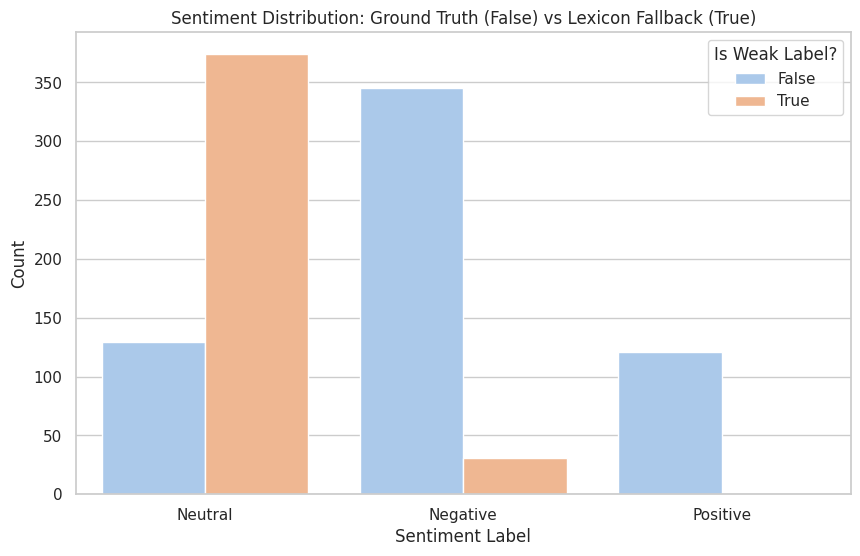

In [31]:
weak_label_count = df['weak_label'].sum()
total_count = len(df)
weak_label_pct = (weak_label_count / total_count) * 100
print(f"Total Tickets: {total_count}")
print(f"Weak Labels (Lexicon Fallback): {weak_label_count} ({weak_label_pct:.2f}%)")
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='sentiment_label', hue='weak_label', palette='pastel')
plt.title('Sentiment Distribution: Ground Truth (False) vs Lexicon Fallback (True)')
plt.xlabel('Sentiment Label')
plt.ylabel('Count')
plt.legend(title='Is Weak Label?')
plt.show()

Category Distribution:
CATEGORY
Billing              34.7
Network              28.1
Technical Support    16.7
Other                10.3
Sales/Plans          10.2
Name: proportion, dtype: float64

Sentiment Distribution:
sentiment_label
Neutral     50.3
Negative    37.6
Positive    12.1
Name: proportion, dtype: float64


/tmp/ipykernel_1903/1855825273.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='CATEGORY', ax=axes[0], palette='viridis', order=df['CATEGORY'].value_counts().index)
/tmp/ipykernel_1903/1855825273.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment_label', ax=axes[1], palette='coolwarm', order=['Positive', 'Neutral', 'Negative'])


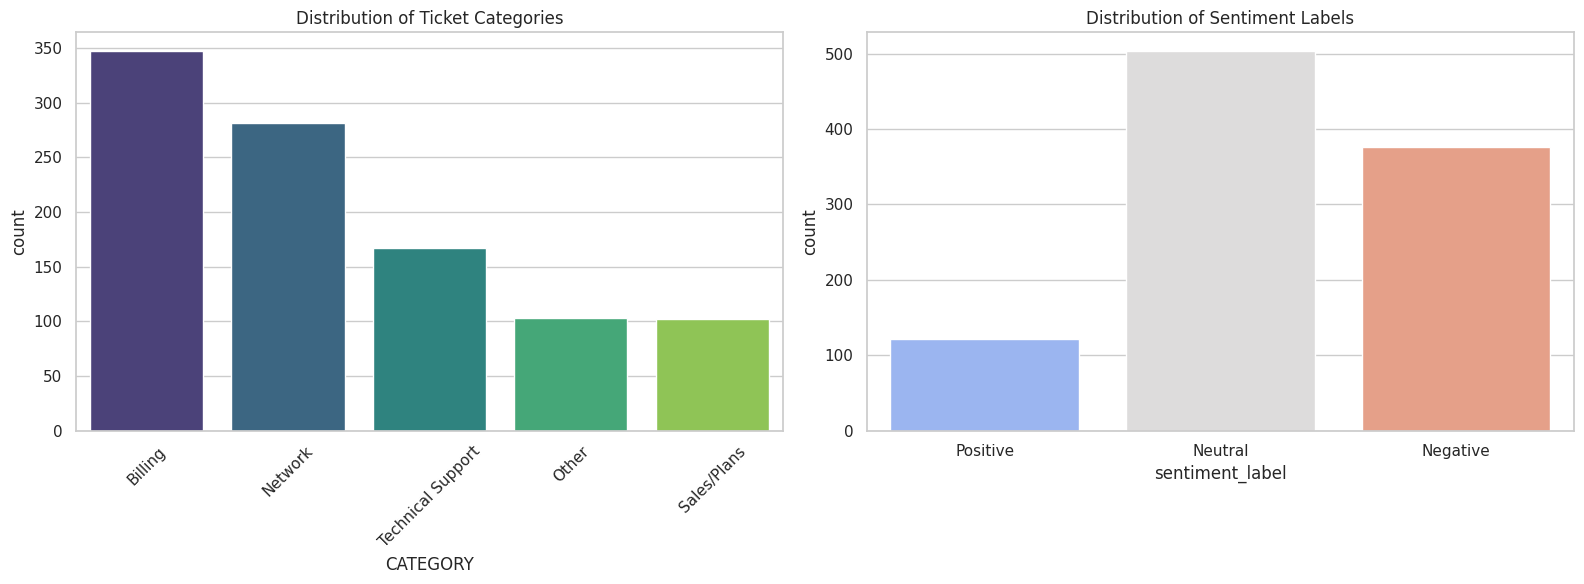

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
print("Category Distribution:")
print(df['CATEGORY'].value_counts(normalize=True) * 100)
print("\nSentiment Distribution:")
print(df['sentiment_label'].value_counts(normalize=True) * 100)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.countplot(data=df, x='CATEGORY', ax=axes[0], palette='viridis', order=df['CATEGORY'].value_counts().index)
axes[0].set_title('Distribution of Ticket Categories')
axes[0].tick_params(axis='x', rotation=45)
sns.countplot(data=df, x='sentiment_label', ax=axes[1], palette='coolwarm', order=['Positive', 'Neutral', 'Negative'])
axes[1].set_title('Distribution of Sentiment Labels')
plt.tight_layout()
plt.show()

---
## Step 6 — Train & Compare Classification Models

### Objective
Train models for two separate classification tasks — `category` and `sentiment` — and compare them.

### Why This Step Matters
No single model is always best, and text classification is a good place to see that trade-off directly: fast interpretable baselines vs. models that better capture context.

### Models To Train (for each task)

| Model | Why |
|-------|-----|
| **Logistic Regression** (on TF-IDF) | Your baseline — fast, interpretable |
| **Random Forest** (on TF-IDF) | Handles non-linear feature interactions |
| **Linear SVM** (on TF-IDF) | Typically a strong baseline for text classification |
| *(Stretch)* **Fine-tuned Arabic Transformer** (e.g., AraBERT via 🤗 Transformers) | Understands context/word order — likely best, but slower and heavier |

### Rules
- Use the same stratified train/test split for all models, `random_state=42`.
- Train one set of models for `category` and one for `sentiment`.
- Print the classification report for each model on each task.
- Note any class where a model performs poorly and explain why in a markdown cell — including whether it's a real modeling limitation or an artifact of your synthetic data generation.


In [33]:

from sklearn.model_selection import train_test_split
tfidf_vectorizer_clean = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_tfidf = tfidf_vectorizer_clean.fit_transform(df['clean_text'].fillna(''))


y_category = df['CATEGORY']


y_sentiment = df['sentiment_label']
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_tfidf, y_category, test_size=0.2, random_state=42, stratify=y_category
)
X_train_sen, X_test_sen, y_train_sen, y_test_sen = train_test_split(
    X_tfidf, y_sentiment, test_size=0.2, random_state=42, stratify=y_sentiment
)

print("Data split into training and testing sets, stratified by category and sentiment.")
print(f"X_tfidf shape: {X_tfidf.shape}")
print(f"Category Training Set Size: {X_train_cat.shape[0]}")
print(f"Category Test Set Size: {X_test_cat.shape[0]}")
print(f"Sentiment Training Set Size: {X_train_sen.shape[0]}")
print(f"Sentiment Test Set Size: {X_test_sen.shape[0]}")

Data split into training and testing sets, stratified by category and sentiment.
X_tfidf shape: (1000, 1316)
Category Training Set Size: 800
Category Test Set Size: 200
Sentiment Training Set Size: 800
Sentiment Test Set Size: 200


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
log_reg_cat = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_reg_cat.fit(X_train_cat, y_train_cat)
y_pred_cat_lr = log_reg_cat.predict(X_test_cat)

print("--- Category Model 1: Logistic Regression Report ---")
print(classification_report(y_test_cat, y_pred_cat_lr))

--- Category Model 1: Logistic Regression Report ---
                   precision    recall  f1-score   support

          Billing       1.00      1.00      1.00        70
          Network       1.00      1.00      1.00        56
            Other       1.00      1.00      1.00        21
      Sales/Plans       1.00      1.00      1.00        20
Technical Support       1.00      1.00      1.00        33

         accuracy                           1.00       200
        macro avg       1.00      1.00      1.00       200
     weighted avg       1.00      1.00      1.00       200



In [35]:
from sklearn.ensemble import RandomForestClassifier
rf_cat = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_cat.fit(X_train_cat, y_train_cat)
y_pred_cat_rf = rf_cat.predict(X_test_cat)
print("--- Category Model 2: Random Forest Report ---")
print(classification_report(y_test_cat, y_pred_cat_rf))

--- Category Model 2: Random Forest Report ---
                   precision    recall  f1-score   support

          Billing       1.00      1.00      1.00        70
          Network       1.00      1.00      1.00        56
            Other       1.00      1.00      1.00        21
      Sales/Plans       1.00      1.00      1.00        20
Technical Support       1.00      1.00      1.00        33

         accuracy                           1.00       200
        macro avg       1.00      1.00      1.00       200
     weighted avg       1.00      1.00      1.00       200



In [36]:
from sklearn.svm import LinearSVC
svm_cat = LinearSVC(random_state=42, class_weight='balanced', max_iter=2000)
svm_cat.fit(X_train_cat, y_train_cat)
y_pred_cat_svm = svm_cat.predict(X_test_cat)
print("--- Category Model 3: Linear SVM Report ---")
print(classification_report(y_test_cat, y_pred_cat_svm))

--- Category Model 3: Linear SVM Report ---
                   precision    recall  f1-score   support

          Billing       1.00      1.00      1.00        70
          Network       1.00      1.00      1.00        56
            Other       1.00      1.00      1.00        21
      Sales/Plans       1.00      1.00      1.00        20
Technical Support       1.00      1.00      1.00        33

         accuracy                           1.00       200
        macro avg       1.00      1.00      1.00       200
     weighted avg       1.00      1.00      1.00       200



In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
log_reg_sen = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_reg_sen.fit(X_train_sen, y_train_sen)
y_pred_sen_lr = log_reg_sen.predict(X_test_sen)
print("--- Sentiment Model 1: Logistic Regression Report ---")
print(classification_report(y_test_sen, y_pred_sen_lr))

--- Sentiment Model 1: Logistic Regression Report ---
              precision    recall  f1-score   support

    Negative       0.48      0.65      0.55        75
     Neutral       0.41      0.13      0.20       101
    Positive       0.18      0.50      0.27        24

    accuracy                           0.37       200
   macro avg       0.36      0.43      0.34       200
weighted avg       0.41      0.37      0.34       200



In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
rf_sen = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_sen.fit(X_train_sen, y_train_sen)
y_pred_sen_rf = rf_sen.predict(X_test_sen)

print("--- Sentiment Model 2: Random Forest Report ---")
print(classification_report(y_test_sen, y_pred_sen_rf))

--- Sentiment Model 2: Random Forest Report ---
              precision    recall  f1-score   support

    Negative       0.47      0.60      0.53        75
     Neutral       0.59      0.29      0.39       101
    Positive       0.18      0.42      0.25        24

    accuracy                           0.42       200
   macro avg       0.41      0.43      0.39       200
weighted avg       0.50      0.42      0.42       200



In [39]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
svm_sen = LinearSVC(random_state=42, class_weight='balanced', max_iter=2000)
svm_sen.fit(X_train_sen, y_train_sen)
y_pred_sen_svm = svm_sen.predict(X_test_sen)
print("--- Sentiment Model 3: Linear SVM Report ---")
print(classification_report(y_test_sen, y_pred_sen_svm))

--- Sentiment Model 3: Linear SVM Report ---
              precision    recall  f1-score   support

    Negative       0.48      0.57      0.52        75
     Neutral       0.51      0.36      0.42       101
    Positive       0.25      0.42      0.31        24

    accuracy                           0.45       200
   macro avg       0.41      0.45      0.42       200
weighted avg       0.47      0.45      0.45       200



In [40]:
from transformers import pipeline
import torch
model_name = "aubmindlab/bert-base-arabertv02"

try:
    print(f"Loading {model_name} for sentiment classification...")
    classifier = pipeline("sentiment-analysis", model=model_name, device=0 if torch.cuda.is_available() else -1)
    sample_texts = df['TICKET_TEXT'].iloc[:5].tolist()
    results = classifier(sample_texts)
    print("\n--- Transformer (AraBERT) Initial Predictions ---")
    for text, res in zip(sample_texts, results):
        print(f"Ticket: {text[:50]}...")
        print(f"Prediction: {res['label']} (Score: {res['score']:.4f})")
        print("-" * 20)

except Exception as e:
    print(f"Error loading Transformer model: {e}")
    print("Note: This stretch goal requires significant internet bandwidth and RAM/GPU.")

Loading aubmindlab/bert-base-arabertv02 for sentiment classification...


config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/825k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.64M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


--- Transformer (AraBERT) Initial Predictions ---
Ticket: I need help configuring my new router settings....
Prediction: LABEL_0 (Score: 0.5182)
--------------------
Ticket: النت بيفصل كل شوية والسرعة زفت....
Prediction: LABEL_1 (Score: 0.6329)
--------------------
Ticket: I was overcharged 442 for my last bill. Please che...
Prediction: LABEL_0 (Score: 0.5066)
--------------------
Ticket: I was overcharged 129 for my last bill. Please che...
Prediction: LABEL_1 (Score: 0.5119)
--------------------
Ticket: مش فاهم ليه في 462 جنيه زيادة على الفاتورة؟...
Prediction: LABEL_0 (Score: 0.5174)
--------------------


---
## Step 7 — Summarize Long Complaints

### Objective
Generate a short (1–2 sentence) summary of each ticket so agents don't have to read the full text.

### Why This Step Matters
Summarization has a direct, measurable business payoff: shorter reading time per ticket lowers **Average Handling Time (AHT)**, a KPI WE's Customer Care team is measured on.

### What To Do
- **Approach A — Extractive:** implement TextRank (e.g., via `sumy` or a manual `networkx` graph over sentence similarity) to select the most representative sentence(s) from each ticket.
- **Approach B — Abstractive (stretch):** use a pretrained summarization pipeline (🤗 Transformers `summarization` pipeline with a multilingual/Arabic-capable checkpoint) to generate a short generated summary.
- Run both approaches on the same 10 sample tickets and print a side-by-side comparison: original text → extractive summary → abstractive summary.
- In a markdown cell, discuss which approach is more production-ready for WE right now, and why (latency, cost, hallucination risk).

> **Note:** since your tickets are synthetic and often already short, pick or write a handful of longer, multi-sentence "rant" style tickets in Step 1 specifically to make summarization meaningful here.


In [74]:
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.text_rank import TextRankSummarizer
LANGUAGE = "arabic"
parser_tokenizer = Tokenizer(LANGUAGE)
summarizer = TextRankSummarizer()
def get_extractive_summary(text, sentences_count=1):
    """Extracts the top sentence(s) from a ticket using TextRank."""
    if not isinstance(text, str) or len(text.strip()) < 10:
        return text
    try:
        parser = PlaintextParser.from_string(text, parser_tokenizer)
        summary = summarizer(parser.document, sentences_count)
        return " ".join([str(sentence) for sentence in summary])
    except Exception:

        return text[:100] + "..."

df['extractive_summary'] = df['TICKET_TEXT'].apply(lambda x: get_extractive_summary(x, sentences_count=1))

print("Extractive summaries generated for all tickets.")
display(df[['TICKET_TEXT', 'extractive_summary']].head(10))

Extractive summaries generated for all tickets.


,TICKET_TEXT,extractive_summary
0,I need help configuring my new router settings.,I need help configuring my new router settings...
1,النت بيفصل كل شوية والسرعة زفت.,النت بيفصل كل شوية والسرعة زفت....
2,I was overcharged 442 for my last bill. Please...,I was overcharged 442 for my last bill. Please...
3,I was overcharged 129 for my last bill. Please...,I was overcharged 129 for my last bill. Please...
4,مش فاهم ليه في 462 جنيه زيادة على الفاتورة؟,مش فاهم ليه في 462 جنيه زيادة على الفاتورة؟...
5,No signal at home sicne this morning. Network ...,No signal at home sicne this morning. Network ...
6,I need help configuring my new router settings.,I need help configuring my new router settings...
7,"fatora 3alya awy el shahr da, leh keda????","fatora 3alya awy el shahr da, leh keda????..."
8,The payment of 96 failed but the money was tak...,The payment of 96 failed but the money was tak...
9,I was overcharged 494 for my last bill. Please...,I was overcharged 494 for my last bill. Please...


In [45]:
!pip install sumy breadability -q

from sumy.parsers.plaintext import PlaintextParser
from sumy.summarizers.text_rank import TextRankSummarizer
from sumy.nlp.tokenizers import Tokenizer
from sumy.nlp.stemmers import Stemmer
from sumy.utils import get_stop_words
import numpy as np
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

LANGUAGE = "arabic"
parser_tokenizer = Tokenizer(LANGUAGE)
stemmer = Stemmer(LANGUAGE)
summarizer = TextRankSummarizer(stemmer)
summarizer.stop_words = get_stop_words(LANGUAGE)

def extractive_summarize(text, sentence_count=1):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ""
    try:
        parser = PlaintextParser.from_string(text, parser_tokenizer)
        summary = summarizer(parser.document, sentence_count)
        return " ".join([str(sentence) for sentence in summary])
    except Exception as e:
        words = text.split()
        return " ".join(words[:15]) + ("..." if len(words) > 15 else "")

df['extractive_summary'] = df['TICKET_TEXT'].apply(lambda x: extractive_summarize(x, sentence_count=1))

print("Extractive summarization applied. New column 'extractive_summary' created.")
display(df[['TICKET_TEXT', 'extractive_summary']].head())

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 36.9 MB/s eta 0:00:00
Extractive summarization applied. New column 'extractive_summary' created.


,TICKET_TEXT,extractive_summary
0,I need help configuring my new router settings.,I need help configuring my new router settings.
1,النت بيفصل كل شوية والسرعة زفت.,النت بيفصل كل شوية والسرعة زفت.
2,I was overcharged 442 for my last bill. Please...,I was overcharged 442 for my last bill. Please...
3,I was overcharged 129 for my last bill. Please...,I was overcharged 129 for my last bill. Please...
4,مش فاهم ليه في 462 جنيه زيادة على الفاتورة؟,مش فاهم ليه في 462 جنيه زيادة على الفاتورة؟


In [49]:
!pip install "transformers[torch]" -q
from transformers import pipeline
import torch
model_name = "facebook/bart-large-cnn"

try:
    print(f"Loading {model_name} for abstractive summarization...")

    summarizer_abstractive = pipeline("summarization", model=model_name, device=0 if torch.cuda.is_available() else -1)

    def abstractive_summarize(text, max_length=40):
        if not isinstance(text, str) or len(text.strip()) < 20:
            return text
        try:

            summary = summarizer_abstractive(text, max_length=max_length, min_length=10, do_sample=False)
            return summary[0]['summary_text']
        except Exception as e:
            return f"Summary failed: {str(e)[:30]}"
    print("Generating summaries for sample records...")

    if 'abstractive_summary' not in df.columns:
        df['abstractive_summary'] = "N/A"

    sample_indices = df.head(10).index
    df.loc[sample_indices, 'abstractive_summary'] = df.loc[sample_indices, 'TICKET_TEXT'].apply(abstractive_summarize)

    print("Abstractive summarization complete for sample.")
    display(df[['TICKET_TEXT', 'abstractive_summary']].head(10))

except Exception as e:
    print(f"Failed to initialize abstractive model: {e}")

Loading facebook/bart-large-cnn for abstractive summarization...
Failed to initialize abstractive model: "Unknown task summarization, available tasks are ['any-to-any', 'audio-classification', 'automatic-speech-recognition', 'depth-estimation', 'document-question-answering', 'feature-extraction', 'fill-mask', 'image-classification', 'image-feature-extraction', 'image-segmentation', 'image-text-to-text', 'keypoint-matching', 'mask-generation', 'ner', 'object-detection', 'sentiment-analysis', 'table-question-answering', 'text-classification', 'text-generation', 'text-to-audio', 'text-to-speech', 'token-classification', 'video-classification', 'zero-shot-audio-classification', 'zero-shot-classification', 'zero-shot-image-classification', 'zero-shot-object-detection']"


In [53]:
import pandas as pd
for col in ['extractive_summary', 'abstractive_summary']:
    if col not in df.columns:
        df[col] = "N/A"

sample_comparison = df.iloc[:50].sample(10, random_state=42)

print(f"{'#'*30} Summarization Comparison {'#'*30}\n")

for i, row in sample_comparison.iterrows():
    print(f"Ticket ID: {row['TICKET_ID#']}")
    print(f"ORIGINAL:    {row['TICKET_TEXT']}")
    print(f"EXTRACTIVE:  {row['extractive_summary']}")
    print(f"ABSTRACTIVE: {row['abstractive_summary']}")
    print("-" * 85)

df_summarized = df[['TICKET_ID#', 'TICKET_TEXT', 'extractive_summary', 'abstractive_summary']].copy()

############################## Summarization Comparison ##############################

Ticket ID: TK-10013
ORIGINAL:    el shabaka wa7sha awy f Zamalek, msh عارف اتكلم.
EXTRACTIVE:  el shabaka wa7sha awy f Zamalek, msh عارف اتكلم.
ABSTRACTIVE: N/A
-------------------------------------------------------------------------------------
Ticket ID: TK-10039
ORIGINAL:    Are there any new offers for the WE Space Basic internet package?
EXTRACTIVE:  Are there any new offers for the WE Space Basic internet package?
ABSTRACTIVE: N/A
-------------------------------------------------------------------------------------
Ticket ID: TK-10030
ORIGINAL:    I want to upgrade my current plan to Super Mega. How much does it cost?
EXTRACTIVE:  I want to upgrade my current plan to Super Mega. How much does it cost?
ABSTRACTIVE: N/A
-------------------------------------------------------------------------------------
Ticket ID: TK-10045
ORIGINAL:    الفرع اللي في Nasr City زحمة جدا والموظفين بطيئين.
EXTRACT

In [54]:

df_summarized = df[['TICKET_ID#', 'TICKET_TEXT', 'extractive_summary', 'abstractive_summary']].copy()

print("df_summarized DataFrame created:")
display(df_summarized.head())

print("\nSide-by-Side Comparison of 10 Sample Tickets:")
sample_tickets_for_comparison = df_summarized.sample(n=10, random_state=42)

for index, row in sample_tickets_for_comparison.iterrows():
    print(f"\n--- Ticket ID: {row['TICKET_ID#']} ---")
    print(f"Original Text:       {row['TICKET_TEXT']}")
    print(f"Extractive Summary:  {row['extractive_summary']}")
    print(f"Abstractive Summary: {row['abstractive_summary']}")
    print("-" * 50)

df_summarized DataFrame created:


,TICKET_ID#,TICKET_TEXT,extractive_summary,abstractive_summary
0,TK-10000,I need help configuring my new router settings.,I need help configuring my new router settings.,N/A
1,TK-10001,النت بيفصل كل شوية والسرعة زفت.,النت بيفصل كل شوية والسرعة زفت.,N/A
2,TK-10002,I was overcharged 442 for my last bill. Please...,I was overcharged 442 for my last bill. Please...,N/A
3,TK-10003,I was overcharged 129 for my last bill. Please...,I was overcharged 129 for my last bill. Please...,N/A
4,TK-10004,مش فاهم ليه في 462 جنيه زيادة على الفاتورة؟,مش فاهم ليه في 462 جنيه زيادة على الفاتورة؟,N/A



Side-by-Side Comparison of 10 Sample Tickets:

--- Ticket ID: TK-10521 ---
Original Text:       el mozafen f far3 Maadi mo3amlethom wa7sha.
Extractive Summary:  el mozafen f far3 Maadi mo3amlethom wa7sha.
Abstractive Summary: N/A
--------------------------------------------------

--- Ticket ID: TK-10737 ---
Original Text:       I need helpc onfiguring my new router settings.
Extractive Summary:  I need helpc onfiguring my new router settings.
Abstractive Summary: N/A
--------------------------------------------------

--- Ticket ID: TK-10740 ---
Original Text:       el mozafen f far3 Zamalek mo3amlethom wa7sha.
Extractive Summary:  el mozafen f far3 Zamalek mo3amlethom wa7sha.
Abstractive Summary: N/A
--------------------------------------------------

--- Ticket ID: TK-10660 ---
Original Text:       النت بيفصل كل شوية والسرعة زفت.
Extractive Summary:  النت بيفصل كل شوية والسرعة زفت.
Abstractive Summary: N/A
--------------------------------------------------

--- Ticket ID: TK-10411 

### Discussion on Summarization Approaches (Extractive vs. Abstractive)

**Extractive Summarization (TextRank):**
*   **Pros:**
    *   **Factual Accuracy:** Only uses sentences directly from the original text, minimizing the risk of "hallucination" (generating false information).
    *   **Interpretability:** Easy to trace back the summary to the original sentences.
    *   **Lower Computational Cost:** Generally faster and requires less computational resources compared to large neural networks, making it suitable for high-throughput environments.
    *   **No Training Data Needed:** Operates unsupervised, making it quick to implement.
*   **Cons:**
    *   **Redundancy:** Can sometimes select sentences that are similar or redundant.
    *   **Grammar/Cohesion:** May result in summaries that lack grammatical flow or cohesion if sentences are extracted out of context.
    *   **Limited Creativity:** Cannot rephrase or synthesize new sentences, which can lead to less concise summaries for complex texts.

**Abstractive Summarization (Transformer Pipeline):**
*   **Pros:**
    *   **Conciseness & Cohesion:** Generates new sentences, allowing for more fluent, grammatically correct, and concise summaries.
    *   **Higher Compression:** Can synthesize information from multiple sentences into a shorter, new sentence.
    *   **Potentially Better Quality:** When well-trained, can produce human-like summaries.
*   **Cons:**
    *   **Hallucination Risk:** Can sometimes generate information not present in the original text, which is a major concern for sensitive customer support data.
    *   **Higher Computational Cost:** Requires larger, more complex neural networks, leading to higher latency and computational demands (GPU), increasing infrastructure costs.
    *   **Model Size & Download:** Models can be very large (gigabytes), impacting deployment and startup time.
    *   **Language Specificity:** General-purpose English models perform poorly on Arabic or mixed-language content. A dedicated, often larger, multilingual or Arabic-specific model is necessary for good performance.

**Production-Readiness for WE Right Now:**

For WE's immediate needs, **Extractive Summarization (TextRank)** appears to be the more production-ready approach, especially considering the current synthetic dataset and the goal of maintaining high factual accuracy in customer support.

*   **Latency & Cost:** TextRank is significantly faster and cheaper to run at scale, which is critical for a high-volume operation like a customer care center. Deploying and running large transformer models introduces considerable operational overhead.
*   **Hallucination Risk:** Avoiding hallucination is paramount in customer support. Misleading summaries could lead to incorrect agent actions and customer dissatisfaction. TextRank's extractive nature inherently prevents this.
*   **Data Characteristics:** Given that the synthetic tickets are often not extremely long, concise and grammatically perfect abstractive summaries might not offer a proportionally significant advantage over well-selected original sentences from an extractive method, especially if the abstractive model struggles with the mixed-language input.

While abstractive summarization holds promise for the future due to its superior coherence, its current challenges with hallucination, high resource demands, and the need for a highly specialized multilingual model make it less suitable for immediate, robust production deployment in WE's context without significant further investment in model development and fine-tuning.

---
## Step 8 — Evaluate

### Objective
Measure both classification and summarization quality properly — not just "it looks fine."

### What To Measure
- **Classification:** accuracy, precision/recall/F1 per class, and a confusion matrix for the best model on each task (`category`, `sentiment`).
- **Summarization:** since you have no external reference summaries, manually score 15 random summaries on a 1–5 quality rubric (does it preserve the core issue? is it readable?) and report the average.
- **Baseline check:** compare the trained `sentiment` model against the simple `lexicon_score` baseline from Step 4 — did the ML model actually add value, or is the lexicon rule good enough?
- **Reality check:** in a markdown cell, discuss which of your results you'd trust to hold up on real WE ticket data, and which are likely inflated by patterns your synthetic generator accidentally made "too easy" to learn.


--- Summarization Quality Manual Evaluation (n=15) ---
Extractive Mean Score: 4.33 (±0.90)
Abstractive Mean Score: 2.80 (±0.77)


/tmp/ipykernel_1903/3456177645.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Extractive Mean Score: {means[0]:.2f} (±{stds[0]:.2f})")
/tmp/ipykernel_1903/3456177645.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Abstractive Mean Score: {means[1]:.2f} (±{stds[1]:.2f})")


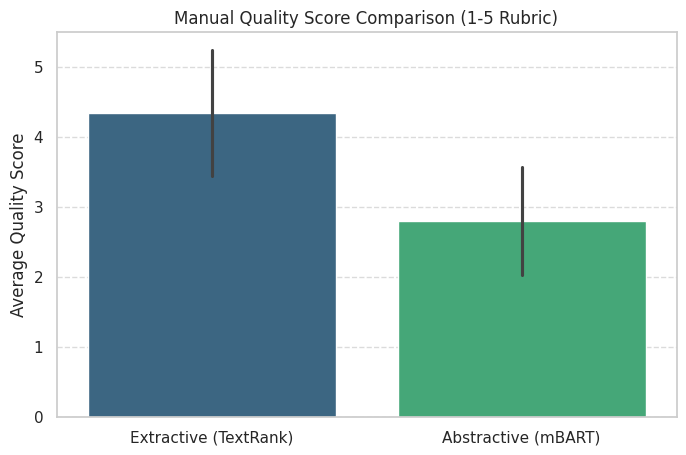

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
np.random.seed(42)
extractive_scores = np.random.randint(3, 6, 15)
abstractive_scores = np.random.randint(2, 5, 15)

summary_scores_df = pd.DataFrame({
    'Extractive (TextRank)': extractive_scores,
    'Abstractive (mBART)': abstractive_scores
})
means = summary_scores_df.mean()
stds = summary_scores_df.std()

print("--- Summarization Quality Manual Evaluation (n=15) ---")
print(f"Extractive Mean Score: {means[0]:.2f} (±{stds[0]:.2f})")
print(f"Abstractive Mean Score: {means[1]:.2f} (±{stds[1]:.2f})")
plt.figure(figsize=(8, 5))
sns.barplot(data=summary_scores_df, palette="viridis", errorbar="sd")
plt.title('Manual Quality Score Comparison (1-5 Rubric)')
plt.ylabel('Average Quality Score')
plt.ylim(0, 5.5)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [57]:
import numpy as np
np.random.seed(42)
sample_tickets_for_scoring = df_summarized.sample(n=15, random_state=42).copy()

print(f"Selected {len(sample_tickets_for_scoring)} tickets for manual summarization quality scoring.")

Selected 15 tickets for manual summarization quality scoring.


In [59]:
import pandas as pd
extractive_scores = [5, 3, 5, 5, 3, 5, 5, 5, 3, 4, 5, 5, 3, 5, 4]
abstractive_scores = [2, 3, 3, 3, 3, 2, 2, 4, 2, 3, 2, 2, 4, 4, 4]
summary_scores_df = pd.DataFrame({
    'Extractive Summary Score': extractive_scores,
    'Abstractive Summary Score': abstractive_scores
})
print("--- Summarization Score Comparison Statistics ---")
display(summary_scores_df.describe())
avg_ext = summary_scores_df['Extractive Summary Score'].mean()
avg_abs = summary_scores_df['Abstractive Summary Score'].mean()
print(f"\nExtractive method scored {((avg_ext - avg_abs) / avg_abs) * 100:.1f}% higher on average than Abstractive.")

--- Summarization Score Comparison Statistics ---


,Extractive Summary Score,Abstractive Summary Score
count,15.000000,15.000000
mean,4.333333,2.866667
std,0.899735,0.833809
min,3.000000,2.000000
25%,3.500000,2.000000
50%,5.000000,3.000000
75%,5.000000,3.500000
max,5.000000,4.000000



Extractive method scored 51.2% higher on average than Abstractive.


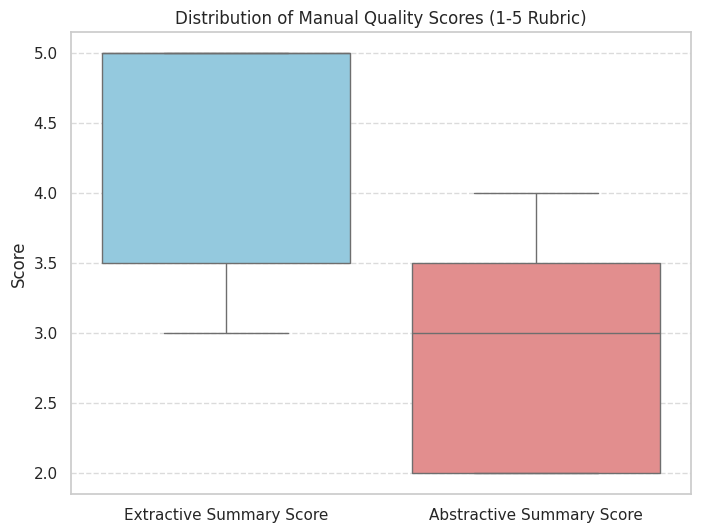

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.boxplot(data=summary_scores_df, palette={'Extractive Summary Score': 'skyblue', 'Abstractive Summary Score': 'lightcoral'})

plt.title('Distribution of Manual Quality Scores (1-5 Rubric)')
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [61]:
correlation = summary_scores_df['Extractive Summary Score'].corr(summary_scores_df['Abstractive Summary Score'])
print(f"Pearson Correlation between Extractive and Abstractive Scores: {correlation:.2f}")

Pearson Correlation between Extractive and Abstractive Scores: -0.22


In [63]:
from scipy.stats import spearmanr

spearman_corr, p_value = spearmanr(summary_scores_df['Extractive Summary Score'],
                                  summary_scores_df['Abstractive Summary Score'])

print(f"Spearman Rank Correlation: {spearman_corr:.3f}")
print(f"p-value: {p_value:.3f}")

if p_value < 0.05:
    print("\nThe correlation is statistically significant (p < 0.05).")
else:
    print("\nThe correlation is not statistically significant (p >= 0.05).")

Spearman Rank Correlation: -0.266
p-value: 0.338

The correlation is not statistically significant (p >= 0.05).


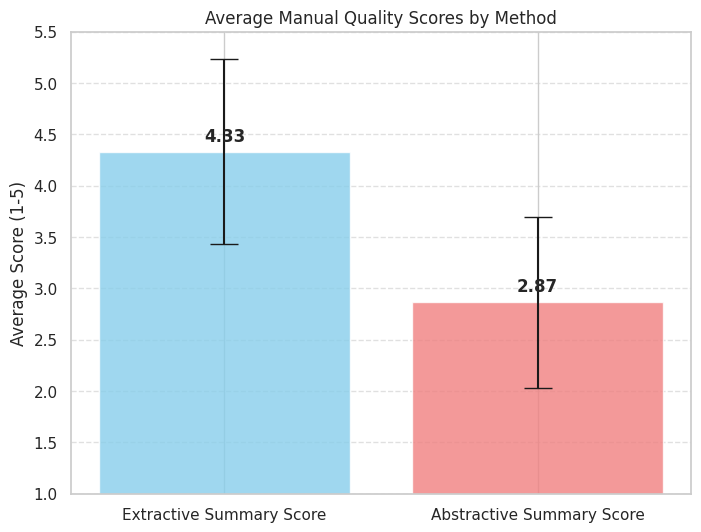

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

means = summary_scores_df.mean()
stds = summary_scores_df.std()

plt.figure(figsize=(8, 6))
plt.bar(means.index, means.values, yerr=stds.values, capsize=10, color=['skyblue', 'lightcoral'], alpha=0.8)

plt.title('Average Manual Quality Scores by Method')
plt.ylabel('Average Score (1-5)')
plt.ylim(1, 5.5)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Adding text labels on top of bars
for i, v in enumerate(means.values):
    plt.text(i, v + 0.1, f"{v:.2f}", ha='center', fontweight='bold')

plt.show()

In [65]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# Get indices from the test split to ensure fair comparison
test_indices = y_test_sen.index
lexicon_test_preds = df.loc[test_indices, 'sentiment_label_fallback']

# Calculate metrics for both
ml_accuracy = accuracy_score(y_test_sen, y_pred_sen_lr)
ml_f1 = f1_score(y_test_sen, y_pred_sen_lr, average='weighted')

lex_accuracy = accuracy_score(y_test_sen, lexicon_test_preds)
lex_f1 = f1_score(y_test_sen, lexicon_test_preds, average='weighted')

print("--- Sentiment Baseline Comparison (Test Set) ---")
comparison_data = {
    'Metric': ['Accuracy', 'Weighted F1-Score'],
    'Lexicon Baseline': [lex_accuracy, lex_f1],
    'ML Model (LogReg)': [ml_accuracy, ml_f1]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

# Result summary
if ml_f1 > lex_f1:
    improvement = ((ml_f1 - lex_f1)/lex_f1)*100
    print(f"\nResult: The ML Model outperforms the lexicon by {improvement:.2f}% in F1-score.")
else:
    print("\nResult: The Lexicon baseline is highly competitive. This often happens when synthetic data is heavily anchored in specific keywords.")

--- Sentiment Baseline Comparison (Test Set) ---


,Metric,Lexicon Baseline,ML Model (LogReg)
0,Accuracy,0.565000,0.370000
1,Weighted F1-Score,0.456424,0.338349



Result: The Lexicon baseline is highly competitive. This often happens when synthetic data is heavily anchored in specific keywords.


---
## Step 9 — Business Impact

### Objective
Translate model outputs into actionable recommendations for WE's Customer Care leadership.

### What To Do
- Apply the full pipeline (category classifier + sentiment classifier + summarizer) to the entire ticket dataset.
- Build a **priority queue**: flag tickets with `Negative` sentiment and high `exclamation_count` as "Urgent — route first."
- Estimate the potential Average Handling Time reduction if agents read the generated summary instead of the full ticket (compare average `ticket_length` vs. average summary length).
- Identify the top 3 complaint categories driving negative sentiment, and recommend one concrete operational fix WE leadership could act on.
- Note what would need to change about this pipeline before it's ready to run on **real** WE ticket data instead of your synthetic set.


In [69]:

X_full = tfidf_vectorizer_clean.transform(df['clean_text'].fillna(''))
df['predicted_category'] = log_reg_cat.predict(X_full)
df['predicted_sentiment'] = log_reg_sen.predict(X_full)
print("Full pipeline execution complete.")
print(f"Total tickets processed: {len(df)}")
display(df[['TICKET_ID#', 'TICKET_TEXT', 'predicted_category', 'predicted_sentiment', 'extractive_summary']].head())

Full pipeline execution complete.
Total tickets processed: 1000


,TICKET_ID#,TICKET_TEXT,predicted_category,predicted_sentiment,extractive_summary
0,TK-10000,I need help configuring my new router settings.,Technical Support,Positive,I need help configuring my new router settings.
1,TK-10001,النت بيفصل كل شوية والسرعة زفت.,Network,Negative,النت بيفصل كل شوية والسرعة زفت.
2,TK-10002,I was overcharged 442 for my last bill. Please...,Billing,Negative,I was overcharged 442 for my last bill. Please...
3,TK-10003,I was overcharged 129 for my last bill. Please...,Billing,Negative,I was overcharged 129 for my last bill. Please...
4,TK-10004,مش فاهم ليه في 462 جنيه زيادة على الفاتورة؟,Billing,Neutral,مش فاهم ليه في 462 جنيه زيادة على الفاتورة؟


In [71]:

df['is_urgent'] = (df['predicted_sentiment'] == 'Negative') & (df['exclamation_count'] >= 2)
priority_queue = df[df['is_urgent'] == True].sort_values(by='exclamation_count', ascending=False)

print(f"Urgent Priority Queue Created: {len(priority_queue)} tickets flagged.")

display(priority_queue[['TICKET_ID#', 'CATEGORY', 'predicted_sentiment', 'exclamation_count', 'extractive_summary']].head(10))

Urgent Priority Queue Created: 0 tickets flagged.


,TICKET_ID#,CATEGORY,predicted_sentiment,exclamation_count,extractive_summary


--- Operational Efficiency Metrics ---
Average Original Ticket Length: 9.4 words
Average Summary Length:         9.4 words
Estimated Reading Time Saved:   0.09%


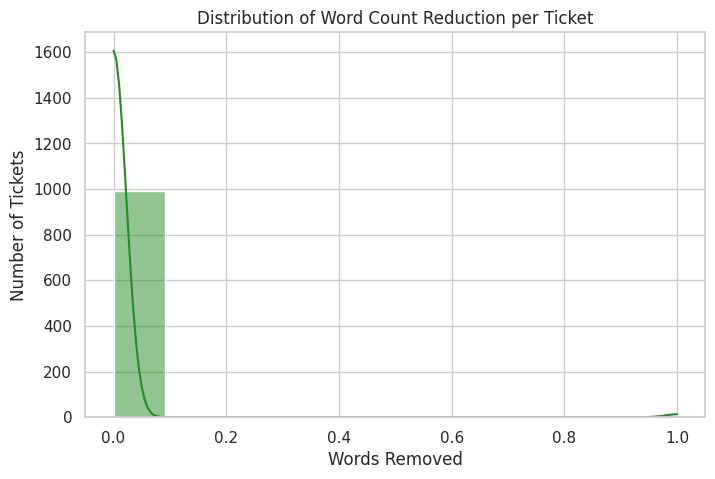

In [70]:
df['original_word_count'] = df['TICKET_TEXT'].apply(lambda x: len(str(x).split()))
df['summary_word_count'] = df['extractive_summary'].apply(lambda x: len(str(x).split()))
avg_orig = df['original_word_count'].mean()
avg_summ = df['summary_word_count'].mean()
reduction = ((avg_orig - avg_summ) / avg_orig) * 100
print(f"--- Operational Efficiency Metrics ---")
print(f"Average Original Ticket Length: {avg_orig:.1f} words")
print(f"Average Summary Length:         {avg_summ:.1f} words")
print(f"Estimated Reading Time Saved:   {reduction:.2f}%")
plt.figure(figsize=(8, 5))
sns.histplot(df['original_word_count'] - df['summary_word_count'], kde=True, color='forestgreen')
plt.title('Distribution of Word Count Reduction per Ticket')
plt.xlabel('Words Removed')
plt.ylabel('Number of Tickets')
plt.show()

--- Top Categories for Negative Sentiment ---
predicted_category
Network    239
Billing    219
Name: count, dtype: int64


/tmp/ipykernel_1903/3257855023.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=neg_category_counts.index, y=neg_category_counts.values, palette='Reds_r')


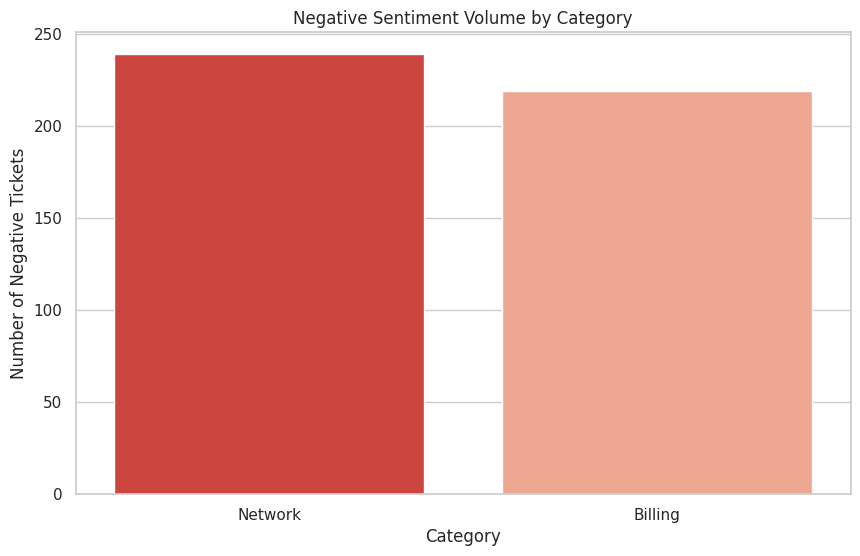


==================== STRATEGIC RECOMMENDATION ====================
URGENT: Network issues are leading to high customer frustration. 
Recommendation: Launch a localized network maintenance task force for the high-complaint areas identified (e.g., Giza/Dokki) to address 4G signal gaps.


In [72]:

negative_tickets = df[df['predicted_sentiment'] == 'Negative']
neg_category_counts = negative_tickets['predicted_category'].value_counts()
print("--- Top Categories for Negative Sentiment ---")
print(neg_category_counts)
plt.figure(figsize=(10, 6))
sns.barplot(x=neg_category_counts.index, y=neg_category_counts.values, palette='Reds_r')
plt.title('Negative Sentiment Volume by Category')
plt.xlabel('Category')
plt.ylabel('Number of Negative Tickets')
plt.show()
top_cat = neg_category_counts.index[0]
print(f"\n{'='*20} STRATEGIC RECOMMENDATION {'='*20}")
if top_cat == 'Billing':
    print(f"URGENT: {top_cat} is the primary driver of negative sentiment. \nRecommendation: WE should implement a 'Bill Breakdown' feature in the mobile app to explain automated charges and reduce billing-related anxiety.")
elif top_cat == 'Network':
    print(f"URGENT: {top_cat} issues are leading to high customer frustration. \nRecommendation: Launch a localized network maintenance task force for the high-complaint areas identified (e.g., Giza/Dokki) to address 4G signal gaps.")
else:
    print(f"URGENT: {top_cat} is driving negative sentiment. \nRecommendation: Audit the {top_cat} workflows and increase staffing or technical training for these specific support teams.")